# Examples for processing Abacus data
For detailed documentation about AbacusSummit, visit https://abacussummit.readthedocs.io/

First, we use the `jax-hod` convenience function for loading AbacusSummit halo catalogs from NERSC and then plot the halo mass function.

In [1]:
import gc
from jaxhod import load_abacus_halos
import matplotlib.pyplot as plt
import numpy as np
%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

SIM_DIR = '/global/cfs/cdirs/desi/public/cosmosim/AbacusSummit'

def get_halos(cosmo=0, phase=0, redshift=0.5):
    return load_abacus_halos(
        sim_dir=SIM_DIR,
        cosmology=f'c{cosmo:03}',
        phase=f'ph{phase:03}',
        redshift=0.5,
    )

def plot_hmf(halos, show=False, label=None):
    bins = np.logspace(10.5, 16, 101)
    hist, bin_edges = np.histogram(halos['masses'], bins=bins)
    
    dlog10M = np.diff(np.log10(bins))
    volume = 2000.0**3.0
    
    massfunc = hist / (dlog10M * volume)
    mass = np.sqrt(bins[:-1] * bins[1:])
    
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(mass, massfunc, label=label)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$M_{\rm halo}\,[h^{-1}M_\odot]$')
    ax.set_ylabel(r'$\mathrm{d}n/\mathrm{d}\log_{10}M\;[h^{3}\,\mathrm{Mpc}^{-3}]$')
    if label is not None:
        ax.legend()
    if show:
        plt.show()
        return
    return ax, fig

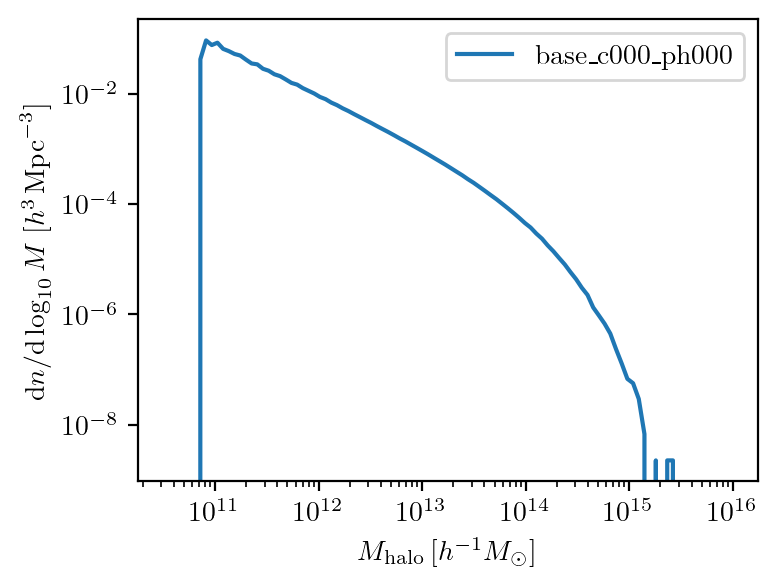

In [2]:
halos = get_halos(cosmo=0, phase=0, redshift=0.5)

plot_hmf(halos, show=True, label=r'$\textrm{base_c000_ph000}$')

## HOD galaxy catalog

Next, we populate the AbacusSummit halos with galaxies using the Zheng et al. (2007) HOD model
(hereafter Zheng07). This model assigns central and satellite galaxies to halos based on their mass.
The mean occupation functions are:

$$\langle N_{\rm cen}(M)\rangle = \frac{1}{2}\left[1 + \mathrm{erf}\!\left(\frac{\log_{10}M - \log_{10}M_{\rm min}}{\sigma_{\log M}}\right)\right]$$

$$\langle N_{\rm sat}(M)\rangle = \langle N_{\rm cen}(M)\rangle \left(\frac{M - M_0}{M_1}\right)^{\alpha}$$

We use `jax-hod`'s `Zheng07` class to define the model parameters and the `populate` function to draw
galaxy positions from the halo catalog.

In [3]:
import jax
from jaxhod import Zheng07, populate

# Zheng+07 HOD parameters (tuned to a typical BOSS-like galaxy sample)
hod_params = dict(
    log_Mmin=13.1,
    sigma_logM=0.35,
    log_M0=13.1,
    log_M1=14.2,
    alpha=1.0,
)

model = Zheng07(**hod_params)

# Populate the halo catalog with galaxies
key = jax.random.PRNGKey(42)
galaxies = populate(
    halo_positions=halos['positions'],
    halo_masses=halos['masses'],
    halo_radii=halos['radii'],
    model=model,
    key=key,
)

n_cen = galaxies['is_central'].sum()
n_sat = (~galaxies['is_central']).sum()
n_tot = len(galaxies['positions'])

print(f"Total galaxies  : {n_tot:,}")
print(f"  Centrals      : {n_cen:,}  ({100*n_cen/n_tot:.1f}%)")
print(f"  Satellites    : {n_sat:,}  ({100*n_sat/n_tot:.1f}%)")
print(f"Number density  : {n_tot / 2000.0**3:.3e}  h^3 Mpc^-3")

E0307 16:15:24.775002 1869475 gpu_hlo_schedule.cc:815] The byte size of input/output arguments (79770274216) exceeds the base limit (31804391424). This indicates an error in the calculation!
E0307 16:15:34.854619 1869475 pjrt_stream_executor_client.cc:2111] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 74.29GiB. [tf-allocator-allocation-error='']


JaxRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 74.29GiB.

### Mean occupation functions

We can inspect the mean number of centrals and satellites as a function of halo mass
predicted by the Zheng07 model.

In [ ]:
masses = np.logspace(11, 16, 500)

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(masses, model.mean_ncen(masses), label=r'$\langle N_{\rm cen}\rangle$')
ax.plot(masses, model.mean_nsat(masses), label=r'$\langle N_{\rm sat}\rangle$')
ax.plot(masses, model.mean_ncen(masses) + model.mean_nsat(masses),
        ls='--', color='k', label=r'$\langle N_{\rm tot}\rangle$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e12, 1e16)
ax.set_ylim(1e-2, 1e2)
ax.set_xlabel(r'$M_{\rm halo}\,[h^{-1}M_\odot]$')
ax.set_ylabel(r'$\langle N \rangle$')
ax.legend()
plt.tight_layout()
plt.show()

### Galaxy positions

We can visualize the spatial distribution of centrals and satellites in a thin slice of the box.

In [ ]:
pos = galaxies['positions']
is_cen = galaxies['is_central']

# Select a 50 Mpc/h slice along the z-axis
slice_mask = (pos[:, 2] > 0) & (pos[:, 2] < 50)
pos_slice = pos[slice_mask]
is_cen_slice = is_cen[slice_mask]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pos_slice[~is_cen_slice, 0], pos_slice[~is_cen_slice, 1],
           s=0.5, alpha=0.4, color='steelblue', label='Satellites', rasterized=True)
ax.scatter(pos_slice[is_cen_slice, 0], pos_slice[is_cen_slice, 1],
           s=1.5, alpha=0.8, color='tomato', label='Centrals', rasterized=True)
ax.set_xlim(0, 2000)
ax.set_ylim(0, 2000)
ax.set_xlabel(r'$x\,[h^{-1}\,\mathrm{Mpc}]$')
ax.set_ylabel(r'$y\,[h^{-1}\,\mathrm{Mpc}]$')
ax.set_title(r'$0 < z < 50\;h^{-1}\,\mathrm{Mpc}$')
ax.legend(markerscale=5, loc='upper right')
plt.tight_layout()
plt.show()

### Varying HOD parameters

We can quickly explore how `log_Mmin` changes the galaxy number density by repopulating the same halo catalog with different models.

In [ ]:
volume = 2000.0 ** 3  # (Mpc/h)^3

log_Mmin_values = [12.8, 13.1, 13.4]
for log_Mmin in log_Mmin_values:
    m = Zheng07(
        log_Mmin=log_Mmin,
        sigma_logM=0.35,
        log_M0=log_Mmin,
        log_M1=log_Mmin + 1.1,
        alpha=1.0,
    )
    res = populate(halos['positions'], halos['masses'], halos['radii'], m, key)
    n_gal = len(res['positions'])
    ng = n_gal / volume
    fsat = (~res['is_central']).sum() / n_gal
    print(f"log_Mmin={log_Mmin:.1f}  →  N_gal={n_gal:,}  "
          f"n_g={ng:.3e} (h/Mpc)^3  f_sat={fsat:.2f}")

### JIT compilation for fast repeated calls

`populate` converts results to NumPy at the end, which is convenient but
prevents it from being JIT-compiled. For MCMC or any loop with many calls,
use the internal `_populate` function, which returns padded JAX arrays and
is fully JIT-compatible, giving a significant speed boost after the first
(compilation) call.

In [ ]:
import time
from jaxhod.populate import _populate

# Wrap _populate with jax.jit, fixing the model and max_satellites
_populate_jit = jax.jit(
    lambda pos, m, r, k: _populate(pos, m, r, model, k, max_satellites=50)
)

pos_jax = jax.numpy.asarray(halos['positions'])
mass_jax = jax.numpy.asarray(halos['masses'])
rad_jax = jax.numpy.asarray(halos['radii'])

# Warm-up: triggers XLA compilation (counted separately)
t_compile = time.perf_counter()
out = _populate_jit(pos_jax, mass_jax, rad_jax, key)
out['positions'].block_until_ready()
t_compile = time.perf_counter() - t_compile
print(f"Compile + first call : {t_compile:.2f} s")

# Timed runs after compilation
n_calls = 5
t0 = time.perf_counter()
for i in range(n_calls):
    k = jax.random.PRNGKey(i)
    out = _populate_jit(pos_jax, mass_jax, rad_jax, k)
    out['positions'].block_until_ready()
t_per_call = (time.perf_counter() - t0) / n_calls
print(f"Mean time per call   : {t_per_call * 1e3:.1f} ms  ({len(halos['masses']):,} halos)")